# Residential Subtype Classification with Heights

This notebook retrains and evaluates the residential subtype classifier after adding LoD2 building-height features.

**Input**
- Preprocessed residential classification data with height features.
- Previously optimized model parameters and selected features.

**Output**
- Evaluated height-enhanced model and final trained classifier.

In [1]:
# Imports & Config

import numpy as np
import pandas as pd
import joblib
import os
import json
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_sample_weight


import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)

ROOT_DIR  = '/fast/home/o-olajuyigbe/osm_project'
ML_DIR    = os.path.join(ROOT_DIR, 'data', 'ml_ready')
MODEL_DIR = os.path.join(ROOT_DIR, 'data', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# Which hierarchical level to train — change this one line to switch levels
# Options: 'flat_l1', 'flat_l2', 'l0_res_binary', 'l1a_res_subtypes',
#          'l1b_ind_binary', 'l2a_ind_subtypes', 'l2b_comm_binary', 'l3a_comm_subtypes'
LEVEL = 'l1a_res_subtypes'

print(f"Training level: {LEVEL}")

Training level: l1a_res_subtypes


/fast/home/o-olajuyigbe/miniforge3/envs/osm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
EXPERIMENT="with_lod2_height"

HEIGHT_FEATURES=[
    "lod2_height_m",
    ]

# Correct height-specific files
train_path=os.path.join(ML_DIR,f"{LEVEL}_train_raw_height.pkl")
val_path=os.path.join(ML_DIR,f"{LEVEL}_val_raw_height.pkl")
test_path=os.path.join(ML_DIR,f"{LEVEL}_test_raw_height.pkl")
classes_path=os.path.join(ML_DIR,f"{LEVEL}_classes_height.pkl")

for path in [train_path,val_path,test_path,classes_path]:
    if not os.path.exists(path): raise FileNotFoundError(path)
    print(f"Found: {path}")

X_train_raw,y_train=joblib.load(train_path)
X_val_raw,y_val=joblib.load(val_path)
X_test_raw,y_test=joblib.load(test_path)
classes=joblib.load(classes_path)
n_classes = len(np.unique(y_train))

print("\nRaw height-split shapes:")
print(f"Train: {X_train_raw.shape}")
print(f"Val  : {X_val_raw.shape}")
print(f"Test : {X_test_raw.shape}")

print("\nHeight columns actually present:")
for col in HEIGHT_FEATURES:
    print(f"{col:<30}: train={col in X_train_raw.columns}, val={col in X_val_raw.columns}, test={col in X_test_raw.columns}")

missing={
    split:[c for c in HEIGHT_FEATURES if c not in X.columns]
    for split,X in [("train",X_train_raw),("val",X_val_raw),("test",X_test_raw)]
}
missing={k:v for k,v in missing.items() if v}

if missing:
    raise KeyError(
        f"Height files exist but do not contain the height columns: {missing}. "
        "Rerun the split-building and saving cells in the height preprocessing notebook."
    )

print("\nTrain height summary:")
display(X_train_raw[HEIGHT_FEATURES].describe().T)

Found: /fast/home/o-olajuyigbe/osm_project/data/ml_ready/l1a_res_subtypes_train_raw_height.pkl
Found: /fast/home/o-olajuyigbe/osm_project/data/ml_ready/l1a_res_subtypes_val_raw_height.pkl
Found: /fast/home/o-olajuyigbe/osm_project/data/ml_ready/l1a_res_subtypes_test_raw_height.pkl
Found: /fast/home/o-olajuyigbe/osm_project/data/ml_ready/l1a_res_subtypes_classes_height.pkl

Raw height-split shapes:
Train: (2929004, 111)
Val  : (172402, 111)
Test : (344749, 111)

Height columns actually present:
lod2_height_m                 : train=True, val=True, test=True

Train height summary:


,count,mean,std,min,25%,50%,75%,max
lod2_height_m,2802038.0,11.023972,4.271737,0.032,8.472,10.023,12.88,141.95


In [3]:
SELECTED_FEATURE_PATH=os.path.join(MODEL_DIR,f"{LEVEL}_feature_cols.pkl")

if not os.path.exists(SELECTED_FEATURE_PATH):
    raise FileNotFoundError(
        f"Previously selected feature list not found:\n{SELECTED_FEATURE_PATH}")

selected_features=list(joblib.load(SELECTED_FEATURE_PATH))

# Append the four LoD2 features without repeating any existing feature
feature_cols=list(dict.fromkeys(selected_features+HEIGHT_FEATURES))

print("\nFeature configuration:")
print(f"Previously selected features: {len(selected_features)}")
print(f"LoD2 features requested      : {len(HEIGHT_FEATURES)}")
print(f"Final model features         : {len(feature_cols)}")

# Check that every required feature exists in every split
split_frames={"train":X_train_raw, "validation":X_val_raw, "test":X_test_raw}

missing_by_split={
    split:[column for column in feature_cols if column not in frame.columns]
    for split,frame in split_frames.items()}

missing_by_split={split:columns for split,columns in missing_by_split.items() if columns}

if missing_by_split:
    for split,columns in missing_by_split.items():
        print(f"\nMissing from {split}:")
        print(columns)

    raise KeyError(
        "The raw ML split files do not contain all selected and LoD2 features. "
        "Rerun ML preprocessing after creating the height features.")

print("\nLoD2 features included:")
for column in HEIGHT_FEATURES:
    print(f"  {column}")


Feature configuration:
Previously selected features: 62
LoD2 features requested      : 1
Final model features         : 63

LoD2 features included:
  lod2_height_m


In [4]:
# Reduce the data strictly to selected features + height features
# ---------------------------------------------------------------------
X_train=X_train_raw[feature_cols].copy()
X_val=X_val_raw[feature_cols].copy()
X_test=X_test_raw[feature_cols].copy()

for column in HEIGHT_FEATURES[1:]:
    X_train[column]=X_train[column].astype("float32")
    X_val[column]=X_val[column].astype("float32")
    X_test[column]=X_test[column].astype("float32")

print("\nFinal datasets:")
print(f"X_train: {X_train.shape}")
print(f"X_val  : {X_val.shape}")
print(f"X_test : {X_test.shape}")


# Save the augmented feature list separately; do not overwrite the baseline
HEIGHT_FEATURE_PATH=os.path.join(
    MODEL_DIR,
    f"{LEVEL}_feature_cols_{EXPERIMENT}.pkl"
)
joblib.dump(feature_cols,HEIGHT_FEATURE_PATH)


Final datasets:
X_train: (2929004, 63)
X_val  : (172402, 63)
X_test : (344749, 63)


['/fast/home/o-olajuyigbe/osm_project/data/models/l1a_res_subtypes_feature_cols_with_lod2_height.pkl']

In [5]:
# Evaluation Helper (used by every model)

def evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, level, threshold=0.5):
    results = {}
    for split_name, X_sp, y_sp in [('val', X_val, y_val), ('test', X_test, y_test)]:
        
        y_pred = model.predict(X_sp).astype(int)

        report = classification_report(y_sp, y_pred, target_names=classes, output_dict=True)
        macro_f1 = f1_score(y_sp, y_pred, average='macro')
        weighted_f1 = f1_score(y_sp, y_pred, average='weighted')
        

        results[split_name] = {
            'macro_f1'   : round(macro_f1, 4),
            'weighted_f1': round(weighted_f1, 4),
            'report'     : report,
        }
        print(f"\n{model_name} — {split_name.upper()} (Decision Threshold: {threshold:.3f})")
        print(f"  Macro F1    : {macro_f1:.4f}")
        print(f"  Weighted F1 : {weighted_f1:.4f}")
        print(classification_report(y_sp, y_pred, target_names=classes, digits=4))

    # Confusion matrix on test 
    y_pred_test = model.predict(X_test).astype(int)

    cm = confusion_matrix(y_test, y_pred_test)
    fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes-1)))
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False)
    ax.set_title(f'{model_name} — {level} — Test Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{level}_{model_name}_confusion.png'), dpi=150)
    plt.show()

    return results


all_results = {}  # accumulates results from all models for comparison

In [6]:
OPTUNA_PATH=os.path.join(MODEL_DIR, f"{LEVEL}_best_hyperparameters.json")

if not os.path.exists(OPTUNA_PATH):
    raise FileNotFoundError(
        f"Saved Optuna parameters not found:\n{OPTUNA_PATH}")

MINORITY_BOOST_LGB = 2.879862860195818
MINORITY_BOOST_XGB = 3.6222038908868215

with open(OPTUNA_PATH,"r") as file:
    saved_optuna=json.load(file)

best_lgb_params=saved_optuna["lightgbm"].copy()
best_xgb_params=saved_optuna["xgboost"].copy()

print("\nSaved Optuna parameters loaded:")
print("\nLightGBM:")
print(best_lgb_params)
print("\nXGBoost:")
print(best_xgb_params)

# Works if minority_boost happens to exist in the saved JSON
final_minority_boost_lgb=float(best_lgb_params.pop("minority_boost",MINORITY_BOOST_LGB))
final_minority_boost_xgb=float(best_xgb_params.pop("minority_boost",MINORITY_BOOST_XGB))

print("\nSaved Optuna parameters loaded.")
print(f"LightGBM minority boost: {final_minority_boost_lgb:.4f}")
print(f"XGBoost minority boost : {final_minority_boost_xgb:.4f}")

def get_sample_weights(y,minority_boost=1.0):
    weights=compute_sample_weight(class_weight="balanced",y=y)
    minority_idx=pd.Series(y).value_counts().idxmin()
    weights=np.asarray(weights,dtype="float64")
    weights[y==minority_idx]*=minority_boost
    return weights

final_sample_weights_lgb=get_sample_weights(y_train,minority_boost=final_minority_boost_lgb)
final_sample_weights_xgb=get_sample_weights(y_train,minority_boost=final_minority_boost_xgb)

minority_idx=pd.Series(y_train).value_counts().idxmin()
print(f"Minority class: {classes[minority_idx]}")


Saved Optuna parameters loaded:

LightGBM:
{'learning_rate': 0.07143768406941398, 'num_leaves': 194, 'min_child_samples': 42, 'subsample': 0.7569392655737687, 'colsample_bytree': 0.7219974784450173, 'reg_alpha': 1.153814682105072, 'reg_lambda': 0.8034649961038726, 'min_split_gain': 0.024869374947388403}

XGBoost:
{'learning_rate': 0.032479939480004674, 'max_depth': 11, 'subsample': 0.7183193614340558, 'colsample_bytree': 0.7305212759063892, 'alpha': 0.26901532494526537, 'lambda': 1.3248236250565142, 'gamma': 0.0010705422769302349, 'min_child_weight': 3}

Saved Optuna parameters loaded.
LightGBM minority boost: 2.8799
XGBoost minority boost : 3.6222
Minority class: TH


In [7]:
trained_models = {}


# 1. Train LightGBM Natively
print(f"\n{'='*60}\nTraining full-scale LIGHTGBM...\n{'='*60}")
lgb_params = {
    'objective': 'multiclass', 'num_class': len(classes), 'metric': 'multi_logloss', 
    'boosting_type': 'gbdt', 'n_estimators': 25000,  'importance_type': 'gain',
    'n_jobs': -1, 'random_state': 42, 'verbosity': -1, **best_lgb_params, 'max_depth': -1
}
model_lgb = lgb.LGBMClassifier(**lgb_params)
model_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)],
              sample_weight=final_sample_weights_lgb, callbacks=[lgb.early_stopping(150), lgb.log_evaluation(200)])

save_path_lgb = os.path.join(MODEL_DIR, f'{LEVEL}_lightgbm_optimized_height.pkl')
joblib.dump(model_lgb, save_path_lgb)
trained_models['lightgbm'] = model_lgb


# 2. Train XGBoost with the explicit sample_weight array injected
print(f"\n{'='*60}\nTraining full-scale XGBOOST...\n{'='*60}")
xgb_params = {
    'objective': 'multi:softprob', 'num_class': len(classes), 'eval_metric': 'mlogloss',
    'n_estimators': 25000, 'tree_method': 'hist', 'importance_type': 'gain',
    'early_stopping_rounds': 150, 'n_jobs': -1, 'random_state': 42, **best_xgb_params
}
model_xgb = xgb.XGBClassifier(**xgb_params)
model_xgb.fit(
    X_train, y_train, 
    sample_weight=final_sample_weights_xgb,
    eval_set=[(X_val, y_val)], 
    verbose=200
)

save_path_xgb = os.path.join(MODEL_DIR, f'{LEVEL}_xgboost_optimized_height.pkl')
joblib.dump(model_xgb, save_path_xgb)
trained_models['xgboost'] = model_xgb


Training full-scale LIGHTGBM...
Training until validation scores don't improve for 150 rounds
[200]	valid_0's multi_logloss: 0.418117
[400]	valid_0's multi_logloss: 0.364729
[600]	valid_0's multi_logloss: 0.330523
[800]	valid_0's multi_logloss: 0.305639
[1000]	valid_0's multi_logloss: 0.285287
[1200]	valid_0's multi_logloss: 0.270085
[1400]	valid_0's multi_logloss: 0.257253
[1600]	valid_0's multi_logloss: 0.246652
[1800]	valid_0's multi_logloss: 0.237425
[2000]	valid_0's multi_logloss: 0.22969
[2200]	valid_0's multi_logloss: 0.22297
[2400]	valid_0's multi_logloss: 0.217231
[2600]	valid_0's multi_logloss: 0.211984
[2800]	valid_0's multi_logloss: 0.207636
[3000]	valid_0's multi_logloss: 0.203717
[3200]	valid_0's multi_logloss: 0.200391
[3400]	valid_0's multi_logloss: 0.197071
[3600]	valid_0's multi_logloss: 0.194042
[3800]	valid_0's multi_logloss: 0.191153
[4000]	valid_0's multi_logloss: 0.188678
[4200]	valid_0's multi_logloss: 0.186376
[4400]	valid_0's multi_logloss: 0.184321
[4600]	va


FINAL TEST SET EVALUATION

lightgbm — VAL (Decision Threshold: 0.500)
  Macro F1    : 0.9397
  Weighted F1 : 0.9394
              precision    recall  f1-score   support

         MFH     0.9479    0.9244    0.9360     73893
         SFH     0.9332    0.9513    0.9421     82110
          TH     0.9343    0.9476    0.9409     16399

    accuracy                         0.9394    172402
   macro avg     0.9384    0.9411    0.9397    172402
weighted avg     0.9396    0.9394    0.9394    172402


lightgbm — TEST (Decision Threshold: 0.500)
  Macro F1    : 0.9399
  Weighted F1 : 0.9399
              precision    recall  f1-score   support

         MFH     0.9485    0.9253    0.9367    147407
         SFH     0.9336    0.9520    0.9427    164720
          TH     0.9353    0.9454    0.9403     32622

    accuracy                         0.9400    344749
   macro avg     0.9391    0.9409    0.9399    344749
weighted avg     0.9401    0.9400    0.9399    344749



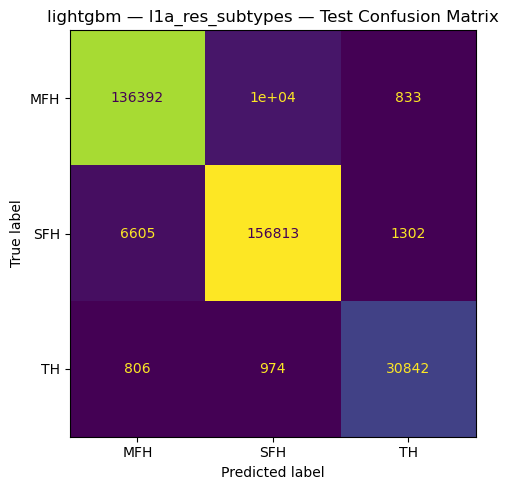


xgboost — VAL (Decision Threshold: 0.500)
  Macro F1    : 0.9415
  Weighted F1 : 0.9408
              precision    recall  f1-score   support

         MFH     0.9491    0.9259    0.9373     73893
         SFH     0.9341    0.9530    0.9434     82110
          TH     0.9395    0.9480    0.9437     16399

    accuracy                         0.9409    172402
   macro avg     0.9409    0.9423    0.9415    172402
weighted avg     0.9410    0.9409    0.9408    172402


xgboost — TEST (Decision Threshold: 0.500)
  Macro F1    : 0.9417
  Weighted F1 : 0.9415
              precision    recall  f1-score   support

         MFH     0.9502    0.9261    0.9380    147407
         SFH     0.9345    0.9544    0.9443    164720
          TH     0.9393    0.9462    0.9428     32622

    accuracy                         0.9415    344749
   macro avg     0.9414    0.9422    0.9417    344749
weighted avg     0.9417    0.9415    0.9415    344749



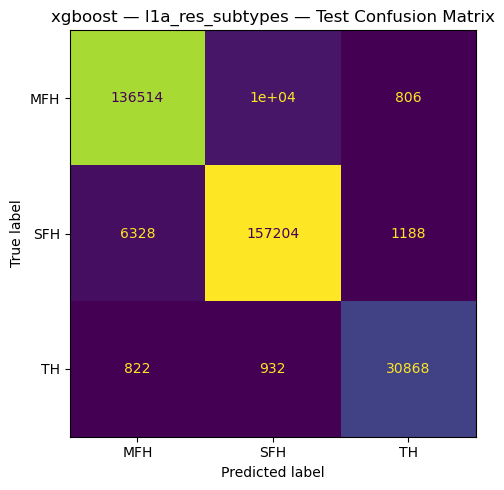

In [8]:
print(f"\n{'='*60}\nFINAL TEST SET EVALUATION\n{'='*60}")
for model_name, model in trained_models.items():
    all_results[model_name] = evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, LEVEL)



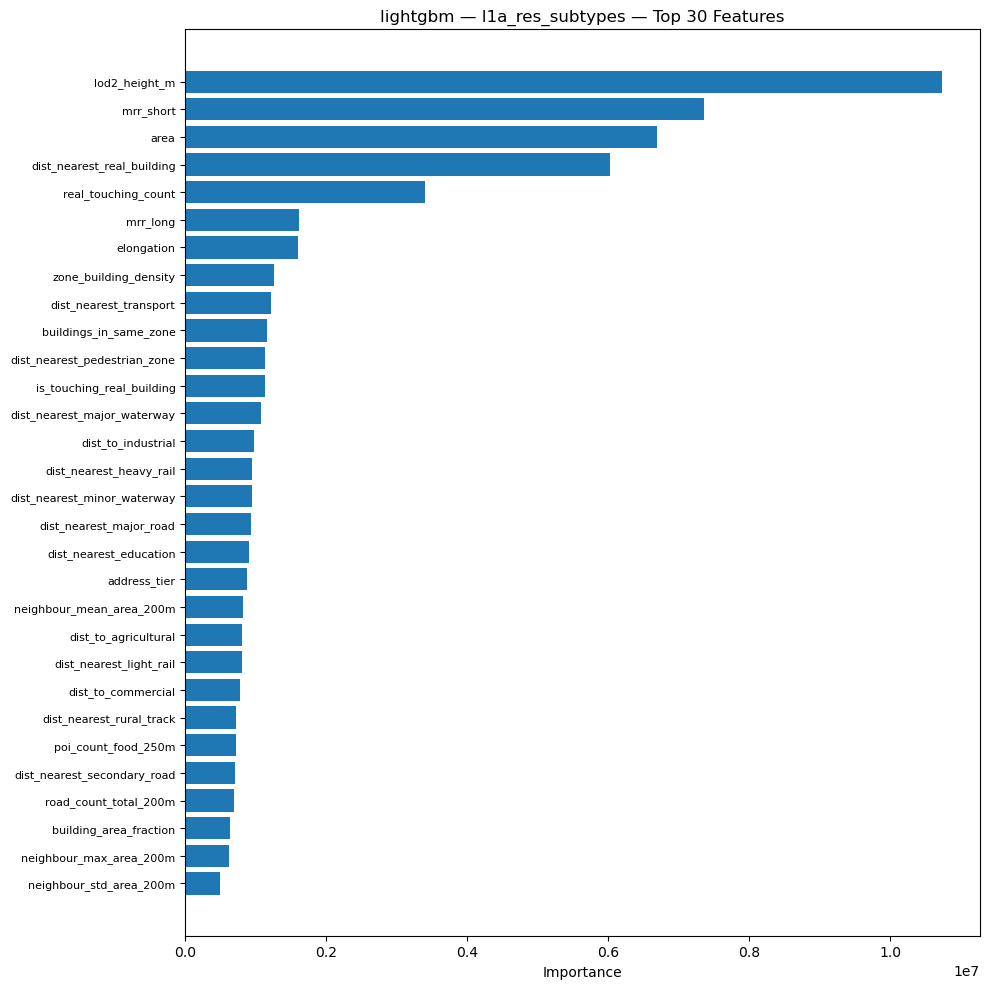

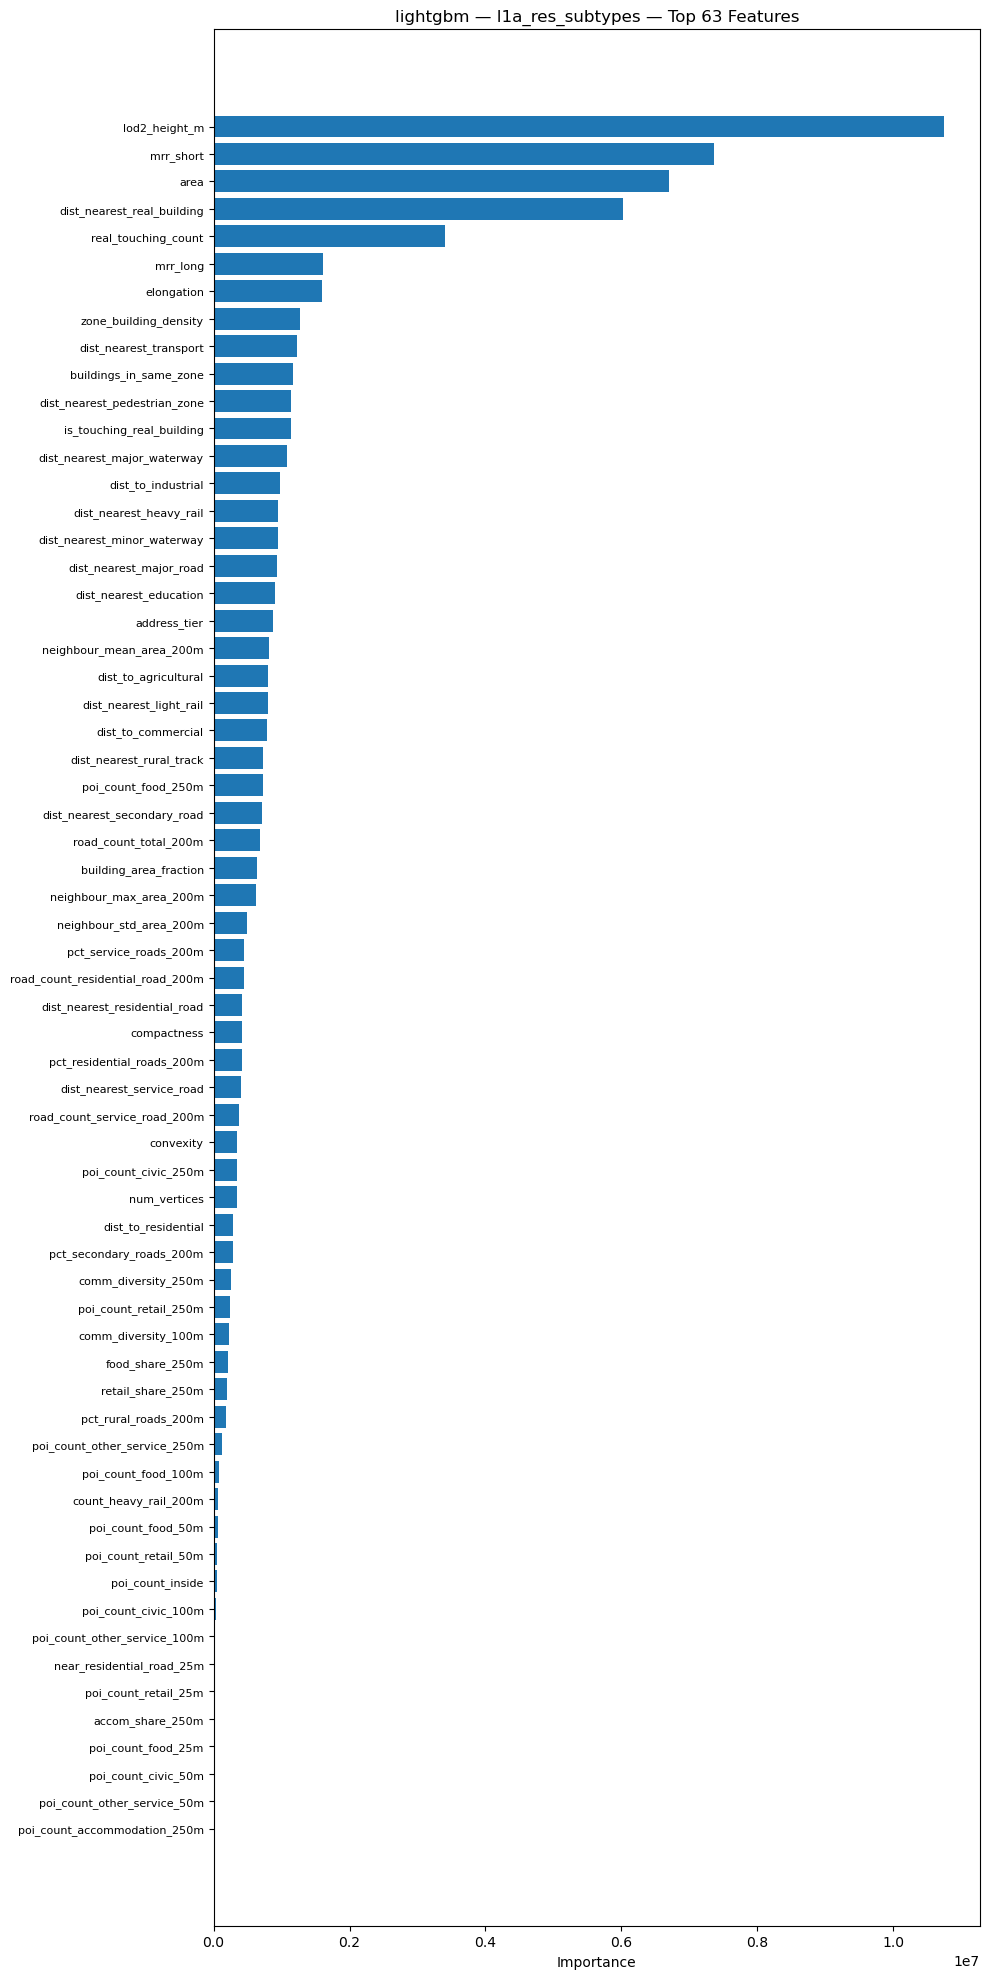

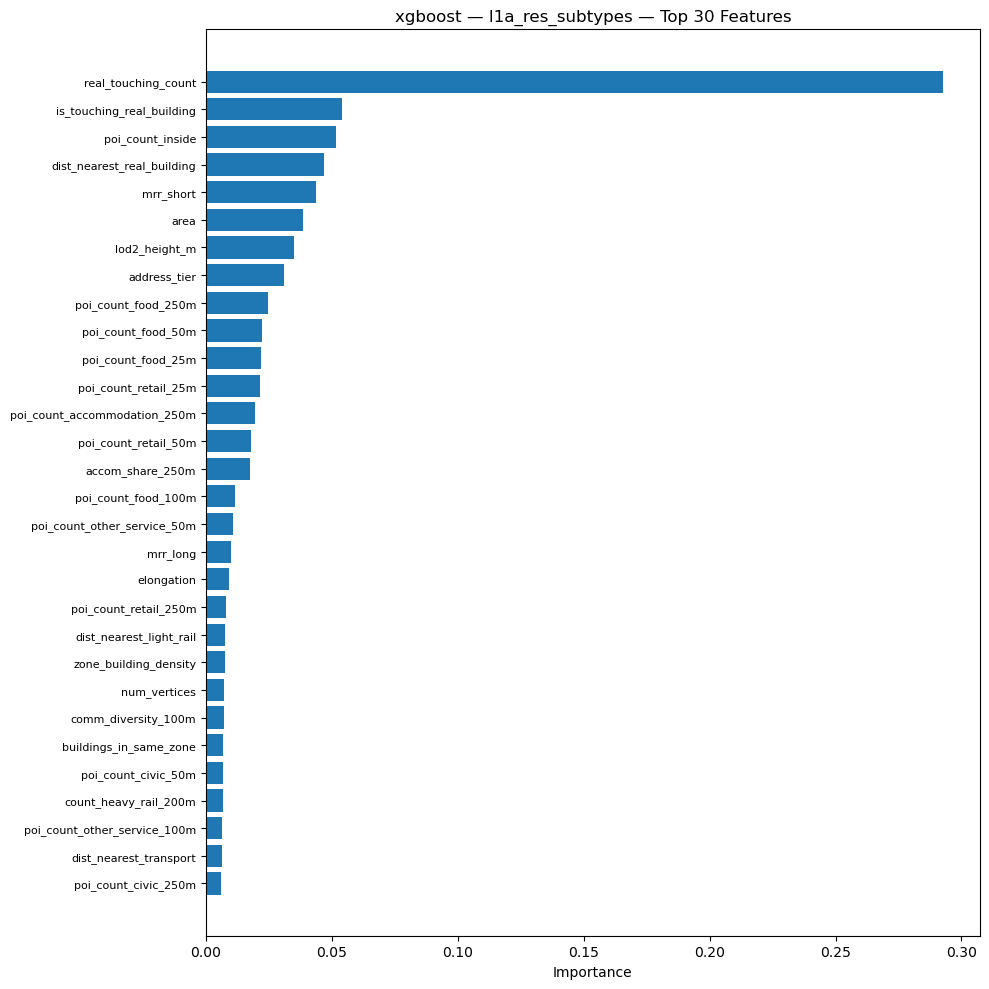

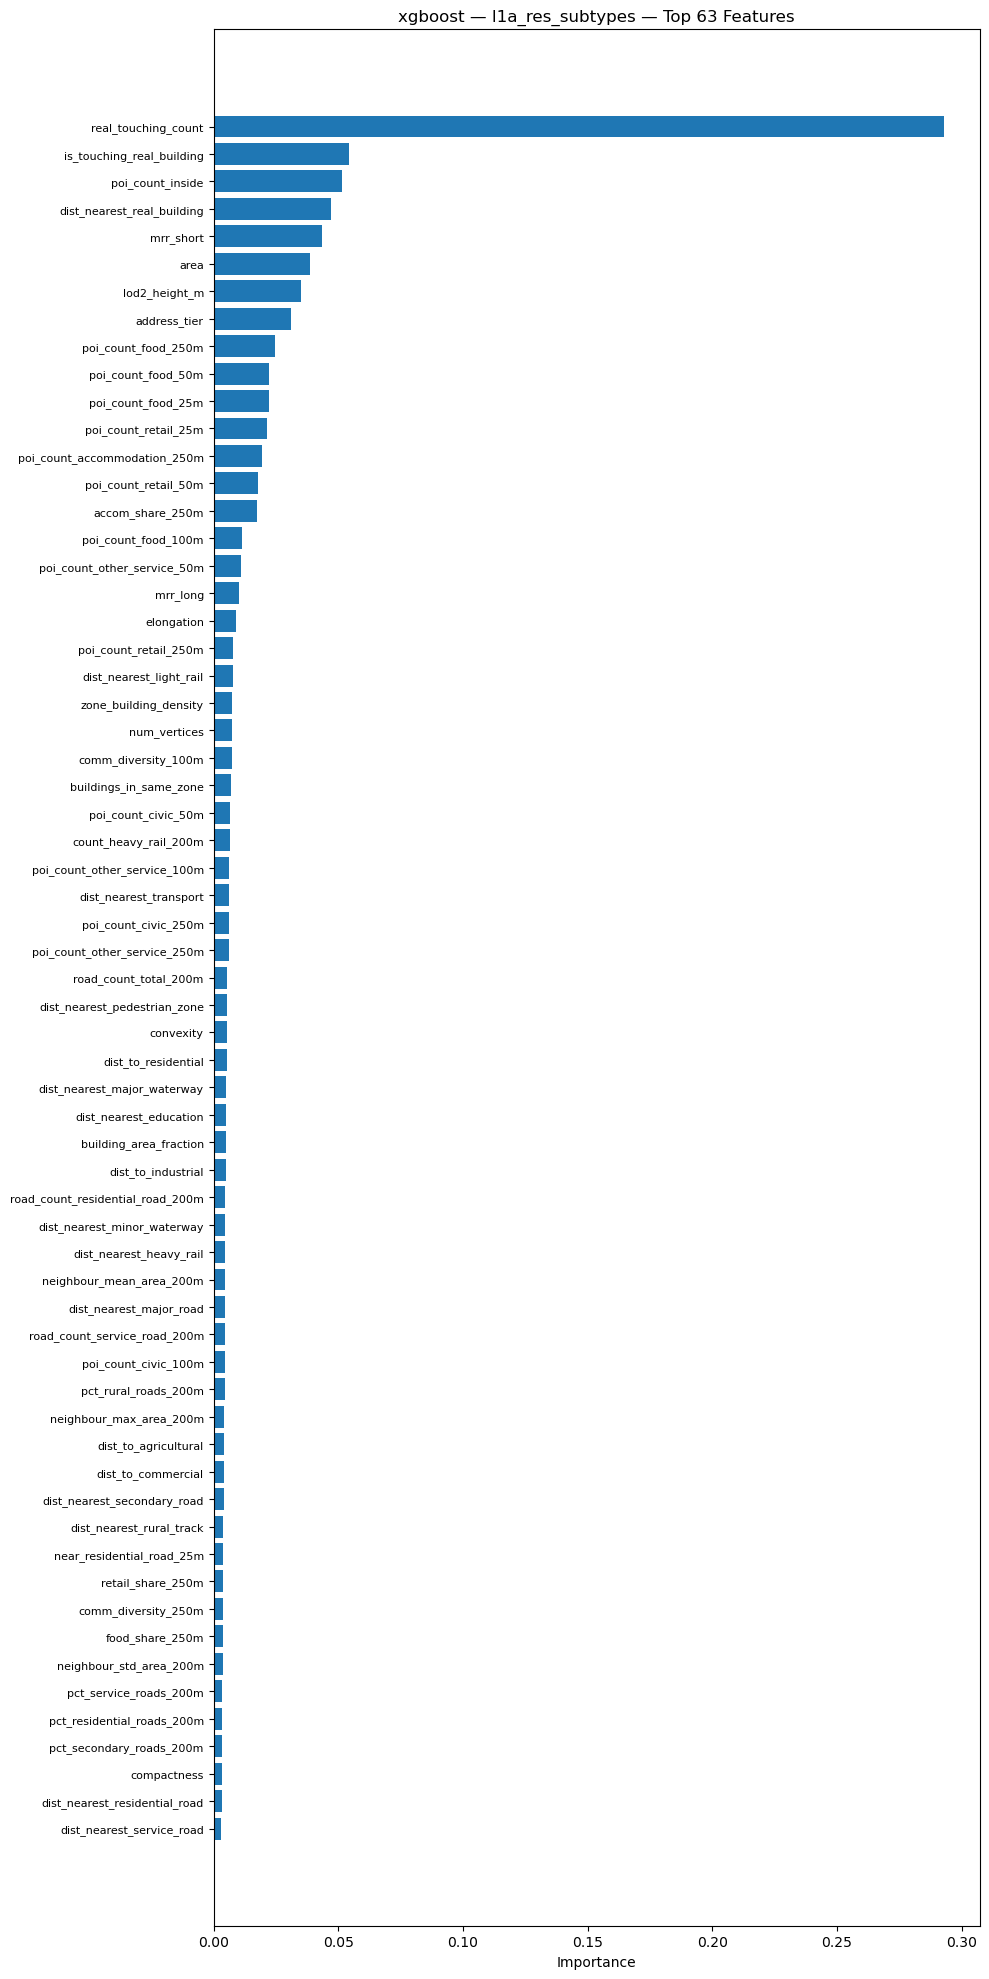

In [9]:
def plot_feature_importance(model, model_name, feature_cols, level, top_n=30):
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    else:
        return

    idx  = np.argsort(imp)[::-1][:top_n]
    fig, ax = plt.subplots(figsize=(10, top_n * 0.3 + 1))
    ax.barh(range(top_n), imp[idx][::-1])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_cols[i] for i in idx[::-1]], fontsize=8)
    ax.set_title(f'{model_name} — {level} — Top {top_n} Features')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

for model_name, model in trained_models.items():
    plot_feature_importance(model, model_name, feature_cols, LEVEL)
    plot_feature_importance(model, model_name, feature_cols, LEVEL, len(feature_cols))

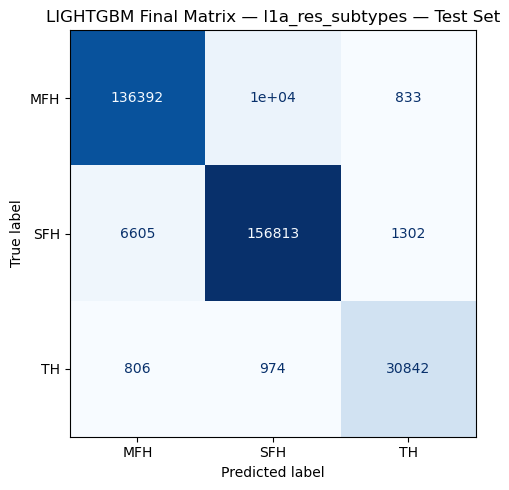

In [10]:
# Generate Visual Confusion Matrix for LightGBM
best_model_name = 'lightgbm'
best_model = trained_models[best_model_name]
final_preds = best_model.predict(X_test).astype(int)

cm = confusion_matrix(y_test, final_preds)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{best_model_name.upper()} Final Matrix — {LEVEL} — Test Set')
plt.tight_layout()
plt.show()

In [11]:
print(f"\n{'='*60}")
print(f"MODEL COMPARISON — {LEVEL} — TEST SET")
print(f"{'='*60}")
print(f"{'Model':<20} {'Macro F1':>10} {'Weighted F1':>13}")
print("-" * 45)

for model_name, res in all_results.items():
    mf1 = res['test']['macro_f1']
    wf1 = res['test']['weighted_f1']
    print(f"{model_name:<20} {mf1:>10.4f} {wf1:>13.4f}")

# Save results to JSON for later aggregation
results_path = os.path.join(MODEL_DIR, f'{LEVEL}_results_height.json')
# Make results JSON-serialisable
serialisable = {
    m: {s: {k: v for k, v in r.items() if k != 'report'}
        for s, r in res.items()}
    for m, res in all_results.items()
}
with open(results_path, 'w') as f:
    json.dump(serialisable, f, indent=2)
print(f"\nResults saved → {results_path}")


MODEL COMPARISON — l1a_res_subtypes — TEST SET
Model                  Macro F1   Weighted F1
---------------------------------------------
lightgbm                 0.9399        0.9399
xgboost                  0.9417        0.9415

Results saved → /fast/home/o-olajuyigbe/osm_project/data/models/l1a_res_subtypes_results_height.json


In [12]:
BEST_MODEL = 'xgboost'  # Options: 'lightgbm' or 'xgboost'
# ────────────────────────────────────────────────────────────────────

print(f"Preparing final production rollout strictly for the winning model: {BEST_MODEL.upper()}")
# Ensure all splits are DataFrames with the same ordered features
def ensure_feature_dataframe(X,feature_cols):
    if isinstance(X,pd.DataFrame):
        return X[feature_cols].copy()
    return pd.DataFrame(X,columns=feature_cols)

X_train_df=ensure_feature_dataframe(X_train,feature_cols)
X_val_df=ensure_feature_dataframe(X_val,feature_cols)
X_test_df=ensure_feature_dataframe(X_test,feature_cols)

if list(X_train_df.columns)!=list(X_val_df.columns):
    raise ValueError("Train and validation features are not aligned.")

if list(X_train_df.columns)!=list(X_test_df.columns):
    raise ValueError("Train and test features are not aligned.")

# Train + test = 95% production-training pool
X_production_train=pd.concat(
    [X_train_df,X_test_df],
    axis=0,
    ignore_index=True
)

y_production_train=np.concatenate([y_train,y_test])

# Keep validation as the early-stopping set
X_production_val=X_val_df
y_production_val = y_val

print(f"Expanded Training Pool Size : {X_production_train.shape[0]:,} rows (95%)")
print(f"Early Stopping Validation Size: {X_production_val.shape[0]:,} rows (5%)")

production_sample_weights = get_sample_weights(
    y_production_train,
    minority_boost=final_minority_boost_lgb if BEST_MODEL == 'lightgbm' else final_minority_boost_xgb
)

if BEST_MODEL == 'lightgbm':
    prod_model = lgb.LGBMClassifier(
        objective='multiclass', num_class=len(classes), metric='multi_logloss', boosting_type='gbdt',
        n_estimators=25000, importance_type='gain',  
        n_jobs=-1, random_state=42, verbosity=-1, **best_lgb_params, max_depth=-1
    )
    prod_model.fit(
        X_production_train, y_production_train,
        sample_weight=production_sample_weights, # Add this line
        eval_set=[(X_production_val, y_production_val)],
        callbacks=[lgb.early_stopping(150), lgb.log_evaluation(200)]
    )
    
elif BEST_MODEL == 'xgboost':
    # Re-calculate balanced scaling array weights on the combined 95% production data matrix
   
    prod_model = xgb.XGBClassifier(
        objective='multi:softprob', num_class=len(classes), eval_metric='mlogloss',
        n_estimators=25000, tree_method='hist',  early_stopping_rounds=150, importance_type='gain',
        n_jobs=-1, random_state=42, **best_xgb_params
    )
    prod_model.fit(
        X_production_train, y_production_train,
        sample_weight=production_sample_weights, 
        eval_set=[(X_production_val, y_production_val)], 
        verbose=200
    )

production_save_path = os.path.join(MODEL_DIR, f'{LEVEL}_xgb_PRODUCTION_FINAL_height.pkl')
joblib.dump(prod_model, production_save_path)
print(f"\n{'='*60}\n✅ ULTIMATE PRODUCTION MODEL DEPLOYED!\n   Saved model to: {production_save_path}\n{'='*60}")

Preparing final production rollout strictly for the winning model: XGBOOST
Expanded Training Pool Size : 3,273,753 rows (95%)
Early Stopping Validation Size: 172,402 rows (5%)
[0]	validation_0-mlogloss:1.54613
[200]	validation_0-mlogloss:0.46825
[400]	validation_0-mlogloss:0.40017
[600]	validation_0-mlogloss:0.35369
[800]	validation_0-mlogloss:0.32063
[1000]	validation_0-mlogloss:0.29505
[1200]	validation_0-mlogloss:0.27544
[1400]	validation_0-mlogloss:0.25980
[1600]	validation_0-mlogloss:0.24645
[1800]	validation_0-mlogloss:0.23535
[2000]	validation_0-mlogloss:0.22580
[2200]	validation_0-mlogloss:0.21774
[2400]	validation_0-mlogloss:0.21059
[2600]	validation_0-mlogloss:0.20432
[2800]	validation_0-mlogloss:0.19881
[3000]	validation_0-mlogloss:0.19398
[3200]	validation_0-mlogloss:0.18975
[3400]	validation_0-mlogloss:0.18596
[3600]	validation_0-mlogloss:0.18271
[3800]	validation_0-mlogloss:0.17979
[4000]	validation_0-mlogloss:0.17719
[4200]	validation_0-mlogloss:0.17489
[4400]	validation